# Complete Pairwise Tanimoto Fold-Distance Plots — Hi Tasks

This notebook generates figures from the fold-distance tables computed in:

`01_tanimoto_distance_tables_hi.ipynb`

No fingerprints, feature importances or distances are recomputed here.

Loaded tables:

- `fold_distance_summary.csv`
- `fold_distance_nn_distributions.csv`
- `fold_distance_activity_vs_random_bits_summary.csv`

The main plotted metric is the complete cross-fold pairwise Tanimoto distance. Nearest-neighbour histograms are shown only as a diagnostic.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from itertools import combinations


def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    current = start
    while current != current.parent:
        if all((current / d).exists() for d in ["data", "utils", "training"]):
            return current
        current = current.parent
    raise RuntimeError("Could not find project root.")


PROJECT_ROOT = find_project_root()

TASK = "hi"
DATASETS_MAIN = ["drd2", "hiv", "sol"]
DATASETS = DATASETS_MAIN

DATASET_LABELS = {"drd2": "DRD2", "hiv": "HIV", "sol": "Sol"}

K_VALUES = [10, 20, 50, 100, 200]

OUT_ROOT = PROJECT_ROOT / "results" / "results_fold_distance_tanimoto" / TASK
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

DATASET_COLORS = {"drd2": "#4C78A8", "hiv": "#F58518", "sol": "#B279A2"}

print("Plot notebook setup completed.")
print(f"OUT_ROOT: {OUT_ROOT}")
print(f"FIG_ROOT: {FIG_ROOT}")

Plot notebook setup completed.
OUT_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi
FIG_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures


In [2]:
dist_path = OUT_ROOT / "fold_distance_summary.csv"
hist_path = OUT_ROOT / "fold_distance_nn_distributions.csv"
summary_path = OUT_ROOT / "fold_distance_activity_vs_random_bits_summary.csv"

if not dist_path.exists():
    raise FileNotFoundError(f"Missing distance table: {dist_path}")

if not hist_path.exists():
    raise FileNotFoundError(f"Missing NN histogram table: {hist_path}")

if not summary_path.exists():
    raise FileNotFoundError(f"Missing final summary table: {summary_path}")

dist_all = pd.read_csv(dist_path)

SUBSETS = ["F1", "F2", "F3"]
PAIRS = list(combinations(SUBSETS, 2))

PAIR_LABELS = {
    "F1_vs_F2": "F1 vs F2",
    "F1_vs_F3": "F1 vs F3",
    "F2_vs_F3": "F2 vs F3",
}
hist_all = pd.read_csv(hist_path)
final_summary = pd.read_csv(summary_path)

print("Loaded plotting tables.")
print(f"dist_all      : {dist_all.shape}")
print(f"hist_all      : {hist_all.shape}")
print(f"final_summary : {final_summary.shape}")

display(dist_all.head())

Loaded plotting tables.
dist_all      : (1494, 23)
hist_all      : (630568, 7)
final_summary : (18, 16)


,dataset,dataset_label,pair,space,k,model,bit_source,activity_protocol,activity_fold,bit_repeat,...,nn_B_to_A_mean,wasserstein_nd,valid_molecule_fraction,n_valid_molecules,n_total_molecules,pairwise_distance,valid_pair_fraction,n_valid_pairs,n_total_pairs,pairwise_mode
0,drd2,DRD2,F1_vs_F2,full_ecfp4,2048,SVM,full_ecfp4,NaN,NaN,NaN,...,0.699229,8.002976,1.000000,2385,2385,0.852592,1.000000,1422054,1422054,complete
1,drd2,DRD2,F1_vs_F2,global_top10,10,SVM,global_activity,pooled,NaN,NaN,...,0.051887,0.861634,0.963522,2298,2385,0.637233,0.998670,1420162,1422054,complete
2,drd2,DRD2,F1_vs_F2,ood_top10,10,SVM,ood_activity,ood,1.0,NaN,...,0.022899,0.829200,0.961426,2293,2385,0.502789,0.998569,1420019,1422054,complete
3,drd2,DRD2,F1_vs_F2,random_top10,10,SVM,random_shuffle_activity,random,1.0,NaN,...,0.030112,0.487541,0.979874,2337,2385,0.534660,0.999620,1421514,1422054,complete
4,drd2,DRD2,F1_vs_F2,random_bits_top10,10,SVM,random_bits,NaN,NaN,0.0,...,0.003527,0.142175,0.150943,360,2385,0.981522,0.279141,396954,1422054,complete


In [3]:
required_dist_cols = [
    "dataset",
    "pair",
    "space",
    "k",
    "bit_source",
    "pairwise_distance",
    "valid_molecule_fraction",
    "valid_pair_fraction",
]

missing = [c for c in required_dist_cols if c not in dist_all.columns]
if missing:
    raise ValueError(f"Missing required columns in dist_all: {missing}")

if dist_all["pairwise_distance"].notna().sum() == 0:
    raise RuntimeError("All pairwise_distance values are NaN.")

assert "kdr" not in set(dist_all["dataset"]), "KDR found in Tanimoto plot table."

print("Sanity checks passed.")
print(
    f"Finite pairwise_distance: "
    f"{dist_all['pairwise_distance'].notna().sum()}/{len(dist_all)}"
)

Sanity checks passed.
Finite pairwise_distance: 1494/1494


In [4]:
def set_plot_style():
    mpl.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 9,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
            "legend.fontsize": 8.5,
            "figure.dpi": 150,
            "savefig.dpi": 600,
            "axes.linewidth": 0.8,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )


def stable_seed(*parts, base: int = 42) -> int:
    import zlib

    s = "|".join(str(p) for p in parts) + f"|{base}"
    return zlib.crc32(s.encode("utf-8")) & 0xFFFFFFFF


def local_rng(*parts) -> np.random.Generator:
    return np.random.default_rng(stable_seed(*parts))


set_plot_style()
print("Plot style configured.")

Plot style configured.


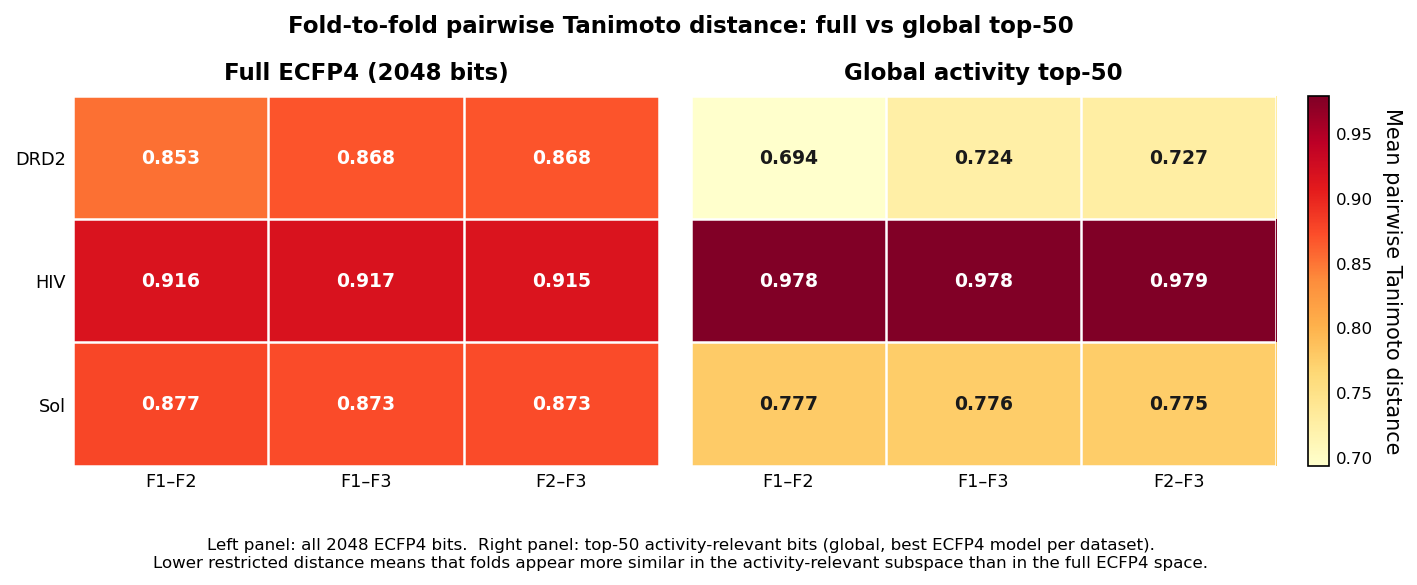

In [ ]:
def fig_distance_heatmap(
    dist_all: pd.DataFrame,
    k_show: int = 50,
    source_prefix: str = "global",
):
    """Heatmap: full ECFP4 vs activity-restricted pairwise Tanimoto distance."""
    set_plot_style()

    src_map = {
        "global": "global_activity",
        "ood": "ood_activity",
        "random": "random_shuffle_activity",
    }
    bit_src = src_map[source_prefix]

    pair_cols = [f"{a}_vs_{b}" for a, b in PAIRS]

    # Build pivot tables: rows = datasets, cols = fold pairs.
    full_sub = dist_all[dist_all["bit_source"] == "full_ecfp4"]
    rest_sub = dist_all[(dist_all["bit_source"] == bit_src) & (dist_all["k"] == k_show)]

    mat_full = (
        full_sub.groupby(["dataset", "pair"], as_index=False)["pairwise_distance"]
        .mean()
        .pivot(index="dataset", columns="pair", values="pairwise_distance")
        .reindex(DATASETS)[pair_cols]
    )
    mat_rest = (
        rest_sub.groupby(["dataset", "pair"], as_index=False)["pairwise_distance"]
        .mean()
        .pivot(index="dataset", columns="pair", values="pairwise_distance")
        .reindex(DATASETS)[pair_cols]
    )

    # Shared color scale across both panels.
    all_vals = np.concatenate(
        [
            mat_full.values[np.isfinite(mat_full.values)],
            mat_rest.values[np.isfinite(mat_rest.values)],
        ]
    )
    vmin = float(all_vals.min()) if len(all_vals) else 0.0
    vmax = float(all_vals.max()) if len(all_vals) else 1.0

    cmap = mpl.colormaps["YlOrRd"].copy()
    cmap.set_bad(color="lightgray")

    fig = plt.figure(figsize=(10.8, 3.2))
    gs = fig.add_gridspec(
        nrows=1,
        ncols=3,
        width_ratios=[1, 1, 0.035],
        wspace=0.08,
    )
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    cax = fig.add_subplot(gs[0, 2])

    titles = {
        0: "Full ECFP4 (2048 bits)",
        1: f"{source_prefix.capitalize()} activity top-{k_show}",
    }
    mats = [mat_full, mat_rest]
    last_im = None

    for idx, (ax, mat) in enumerate(zip(axes, mats)):
        data = np.ma.masked_invalid(mat.values.astype(float))
        last_im = ax.imshow(
            data,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            aspect="auto",
            interpolation="nearest",
        )

        ax.set_title(titles[idx], fontweight="bold", pad=8)
        ax.set_xticks(range(mat.shape[1]))
        ax.set_xticklabels(
            [c.replace("_vs_", "–") for c in mat.columns],
            rotation=0,
            ha="center",
        )
        ax.set_yticks(range(mat.shape[0]))
        ax.set_yticklabels([DATASET_LABELS.get(d, d) for d in mat.index])

        ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.2)
        ax.tick_params(which="minor", bottom=False, left=False)
        ax.tick_params(axis="both", length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat.iloc[i, j]
                if pd.notna(v):
                    mid = (vmin + vmax) / 2
                    text_color = "white" if v >= mid else "0.10"
                    ax.text(
                        j,
                        i,
                        f"{v:.3f}",
                        ha="center",
                        va="center",
                        fontsize=9,
                        fontweight="bold",
                        color=text_color,
                    )

    axes[1].tick_params(labelleft=False)

    cbar = fig.colorbar(last_im, cax=cax)
    cbar.set_label("Mean pairwise Tanimoto distance", rotation=270, labelpad=14)
    cbar.ax.tick_params(length=0, labelsize=8)

    fig.suptitle(
        f"Fold-to-fold pairwise Tanimoto distance: full vs {source_prefix} top-{k_show}",
        fontweight="bold",
        y=1.05,
        fontsize=11,
    )

    fig.text(
        0.5,
        -0.04,
        f"Left panel: all 2048 ECFP4 bits.  Right panel: top-{k_show} activity-relevant bits "
        f"({source_prefix}, best ECFP4 model per dataset).\n"
        "Lower restricted distance means that folds appear more similar in the activity-relevant subspace than in the full ECFP4 space.",
        ha="center",
        va="top",
        fontsize=8,
    )

    fname = FIG_ROOT / f"fig1_distance_heatmap_full_vs_{source_prefix}_top{k_show}"
    fig.savefig(f"{fname}.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


fig_distance_heatmap(dist_all, k_show=50, source_prefix="global")

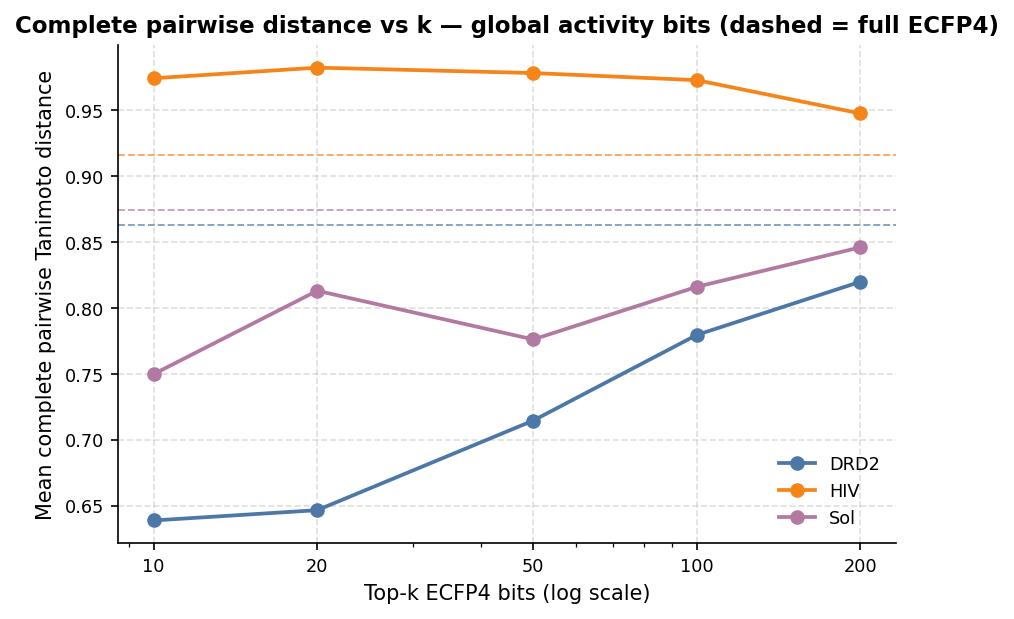

Figure 2 generated.


In [6]:
def fig_distance_vs_k(dist_all: pd.DataFrame, source_prefix: str = "global"):
    set_plot_style()

    src_map = {
        "global": "global_activity",
        "ood": "ood_activity",
        "random": "random_shuffle_activity",
    }
    bit_src = src_map[source_prefix]

    sub = dist_all[dist_all["bit_source"] == bit_src]
    full = dist_all[dist_all["bit_source"] == "full_ecfp4"]

    fig, ax = plt.subplots(figsize=(6.0, 4.2))
    for ds in DATASETS:
        sub_d = (
            sub[sub["dataset"] == ds]
            .groupby("k", as_index=False)["pairwise_distance"]
            .mean()
            .sort_values("k")
        )
        if sub_d.empty:
            continue
        ax.plot(
            sub_d["k"],
            sub_d["pairwise_distance"],
            marker="o",
            lw=1.8,
            color=DATASET_COLORS.get(ds, "C0"),
            label=DATASET_LABELS[ds],
        )

        full_d = full[full["dataset"] == ds]["pairwise_distance"].mean()
        if np.isfinite(full_d):
            ax.axhline(
                full_d, ls="--", lw=0.9, color=DATASET_COLORS.get(ds, "C0"), alpha=0.7
            )

    ax.set_xscale("log")
    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([str(k) for k in K_VALUES])
    ax.set_xlabel("Top-k ECFP4 bits (log scale)")
    ax.set_ylabel("Mean complete pairwise Tanimoto distance")
    ax.set_title(
        f"Complete pairwise distance vs k — {source_prefix} activity bits "
        "(dashed = full ECFP4)",
        fontweight="bold",
    )
    ax.grid(ls="--", alpha=0.4)
    ax.legend(frameon=False)

    fname = FIG_ROOT / f"fig2_pairwise_distance_vs_k_{source_prefix}"
    fig.tight_layout()
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


fig_distance_vs_k(dist_all, source_prefix="global")
print("Figure 2 generated.")

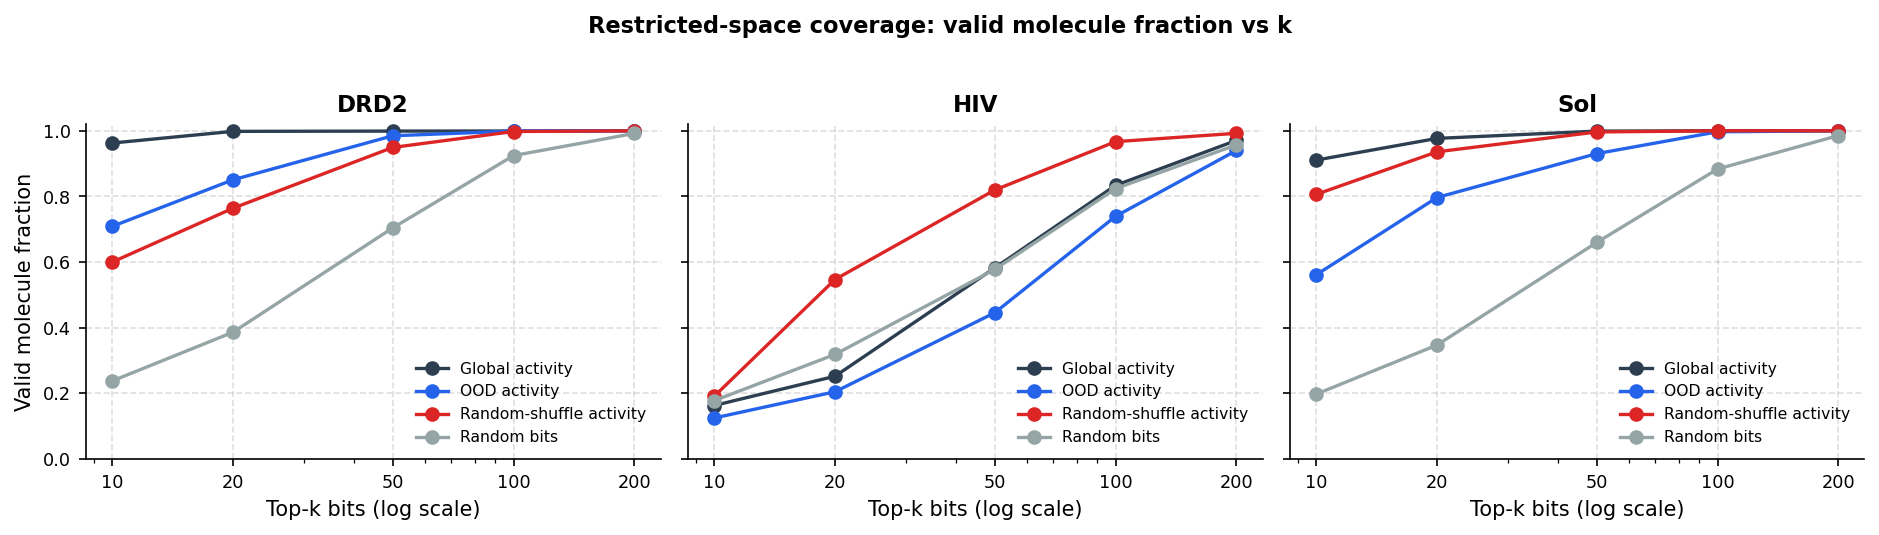

Figure 6 generated.


In [7]:
def fig_valid_fraction_vs_k(dist_all: pd.DataFrame):
    set_plot_style()
    datasets = [d for d in DATASETS if d in dist_all["dataset"].unique()]
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.4), sharey=True, squeeze=False)

    series = [
        ("global_activity", "Global activity", "#2C3E50"),
        ("ood_activity", "OOD activity", "#2563EB"),
        ("random_shuffle_activity", "Random-shuffle activity", "#DC2626"),
        ("random_bits", "Random bits", "#95A5A6"),
    ]

    for ax, ds in zip(axes[0], datasets):
        for src, label, color in series:
            sub = (
                dist_all[(dist_all["dataset"] == ds) & (dist_all["bit_source"] == src)]
                .groupby("k", as_index=False)["valid_molecule_fraction"]
                .mean()
                .sort_values("k")
            )
            if sub.empty:
                continue
            ax.plot(
                sub["k"],
                sub["valid_molecule_fraction"],
                marker="o",
                lw=1.6,
                color=color,
                label=label,
            )

        ax.set_xscale("log")
        ax.set_xticks(K_VALUES)
        ax.set_xticklabels([str(k) for k in K_VALUES])
        ax.set_ylim(0, 1.02)
        ax.set_xlabel("Top-k bits (log scale)")
        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.grid(ls="--", alpha=0.4)
        ax.legend(frameon=False, fontsize=7.5)

    axes[0, 0].set_ylabel("Valid molecule fraction")
    fig.suptitle(
        "Restricted-space coverage: valid molecule fraction vs k",
        fontweight="bold",
        y=1.03,
    )
    fig.tight_layout()
    fname = FIG_ROOT / "fig6_valid_fraction_vs_k"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


fig_valid_fraction_vs_k(dist_all)
print("Figure 6 generated.")

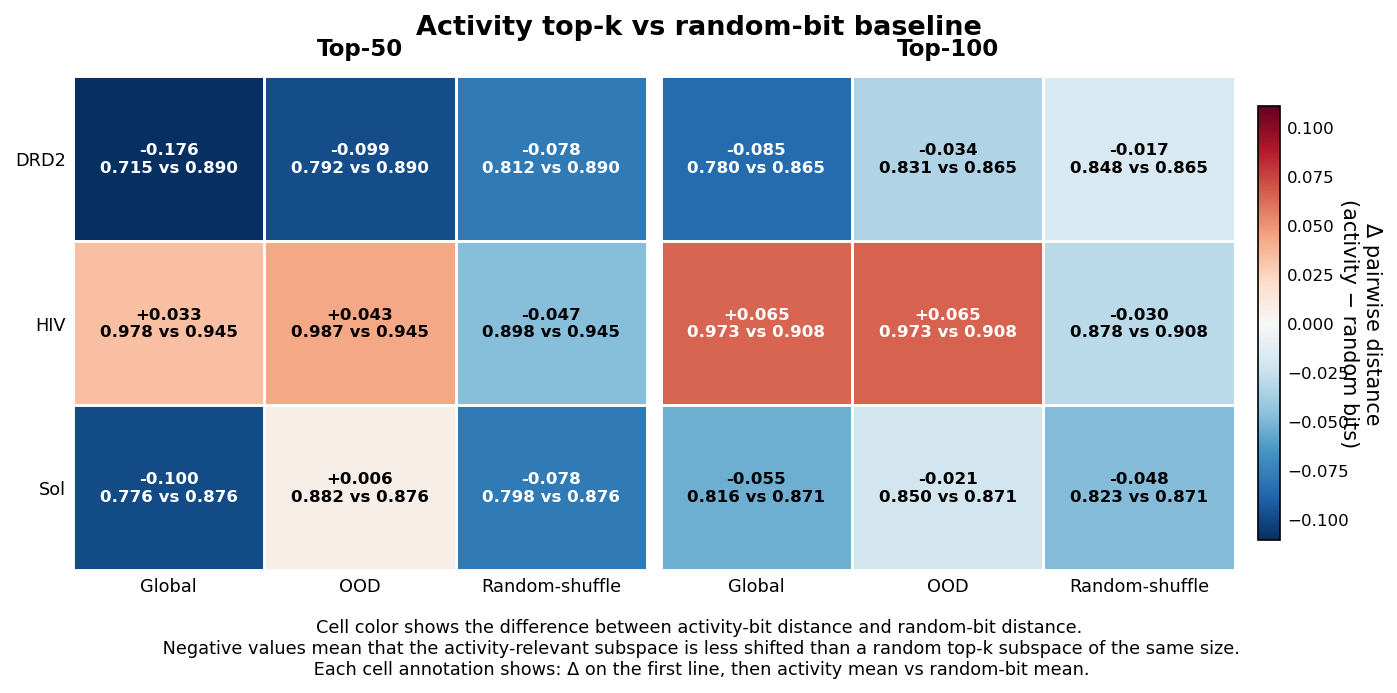

In [ ]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib as mpl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def fig_activity_vs_random_bits_heatmap(
    dist_all: pd.DataFrame,
    k_values=(50, 100),
):
    set_plot_style()

    activity_sources = [
        ("global_activity", "Global"),
        ("ood_activity", "OOD"),
        ("random_shuffle_activity", "Random-shuffle"),
    ]

    rows = []

    for k_show in k_values:
        for ds in DATASETS:
            rb = dist_all[
                (dist_all["dataset"] == ds)
                & (dist_all["bit_source"] == "random_bits")
                & (pd.to_numeric(dist_all["k"], errors="coerce") == k_show)
            ]

            if rb.empty:
                continue

            rb_mean = rb["pairwise_distance"].mean()

            for src, src_label in activity_sources:
                sub = dist_all[
                    (dist_all["dataset"] == ds)
                    & (dist_all["bit_source"] == src)
                    & (pd.to_numeric(dist_all["k"], errors="coerce") == k_show)
                ]

                if sub.empty:
                    continue

                act_mean = sub["pairwise_distance"].mean()
                delta = act_mean - rb_mean

                rows.append(
                    {
                        "dataset": ds,
                        "dataset_label": DATASET_LABELS.get(ds, ds),
                        "k": k_show,
                        "source": src,
                        "source_label": src_label,
                        "activity_mean": act_mean,
                        "random_bits_mean": rb_mean,
                        "delta_vs_random": delta,
                    }
                )

    plot_df = pd.DataFrame(rows)

    if len(plot_df) == 0:
        print("No rows available for activity-vs-random heatmap.")
        return

    # robust symmetric scale around 0
    finite_vals = plot_df["delta_vs_random"].replace([np.inf, -np.inf], np.nan).dropna()
    if len(finite_vals) == 0:
        print("No finite delta values available.")
        return

    vmax = max(np.nanpercentile(np.abs(finite_vals), 95), 0.02)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    cmap = mpl.colormaps["RdBu_r"].copy()
    cmap.set_bad(color="lightgray")

    fig, axes = plt.subplots(
        1,
        len(k_values),
        figsize=(4.6 * len(k_values), 3.8),
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )

    for ax, k_show in zip(axes[0], k_values):
        sub = plot_df[plot_df["k"] == k_show].copy()

        mat_delta = (
            sub.pivot(
                index="dataset_label", columns="source_label", values="delta_vs_random"
            )
            .reindex(
                index=[
                    DATASET_LABELS[d]
                    for d in DATASETS
                    if d in plot_df["dataset"].unique()
                ]
            )
            .reindex(columns=["Global", "OOD", "Random-shuffle"])
        )

        mat_act = sub.pivot(
            index="dataset_label", columns="source_label", values="activity_mean"
        ).reindex(index=mat_delta.index, columns=mat_delta.columns)

        mat_rb = sub.pivot(
            index="dataset_label", columns="source_label", values="random_bits_mean"
        ).reindex(index=mat_delta.index, columns=mat_delta.columns)

        data = np.ma.masked_invalid(mat_delta.values.astype(float))

        im = ax.imshow(
            data,
            cmap=cmap,
            norm=norm,
            aspect="auto",
            interpolation="nearest",
        )

        ax.set_title(f"Top-{k_show}", fontweight="bold", pad=10)
        ax.set_xticks(np.arange(mat_delta.shape[1]))
        ax.set_xticklabels(mat_delta.columns, rotation=0, ha="center")
        ax.set_yticks(np.arange(mat_delta.shape[0]))
        ax.set_yticklabels(mat_delta.index)

        ax.set_xticks(np.arange(-0.5, mat_delta.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, mat_delta.shape[0], 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.4)
        ax.tick_params(which="minor", bottom=False, left=False)
        ax.tick_params(axis="both", length=0)

        for spine in ax.spines.values():
            spine.set_visible(False)

        for i in range(mat_delta.shape[0]):
            for j in range(mat_delta.shape[1]):
                delta_val = mat_delta.iloc[i, j]
                act_val = mat_act.iloc[i, j]
                rb_val = mat_rb.iloc[i, j]

                if pd.notna(delta_val):
                    text_color = "white" if abs(delta_val) >= 0.55 * vmax else "black"

                    label = f"{delta_val:+.3f}\n" f"{act_val:.3f} vs {rb_val:.3f}"

                    ax.text(
                        j,
                        i,
                        label,
                        ha="center",
                        va="center",
                        fontsize=8,
                        color=text_color,
                        fontweight="bold",
                    )

    cbar = fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        shrink=0.88,
        pad=0.02,
    )
    cbar.set_label(
        "Δ pairwise distance\n(activity − random bits)",
        rotation=270,
        labelpad=16,
    )
    cbar.ax.tick_params(length=0, labelsize=8)

    fig.suptitle(
        "Activity top-k vs random-bit baseline",
        fontsize=13,
        fontweight="bold",
        y=1.03,
    )

    fig.text(
        0.5,
        -0.03,
        "Cell color shows the difference between activity-bit distance and random-bit distance.\n "
        "Negative values mean that the activity-relevant subspace is less shifted than a random top-k subspace "
        "of the same size.\n Each cell annotation shows: Δ on the first line, then activity mean vs random-bit mean.",
        ha="center",
        va="top",
        fontsize=8.5,
    )

    fname = FIG_ROOT / "fig_activity_vs_random_bits_heatmap_delta"
    fig.savefig(f"{fname}.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")

    plt.show()
    plt.close(fig)


fig_activity_vs_random_bits_heatmap(dist_all, k_values=(50, 100))